In [1]:
import matplotlib.pyplot as plt
import yfinance as yf

tickers=["^GSPC",'^NY','^IXIC','^DJUS','^STOXX50E','^FCHI','^GDAXI']
raw_train_df= yf.download(tickers, start="2023-01-02", end="2024-12-21")
train_df=raw_train_df['Close'].dropna()
renaming_dict={'^GSPC':'SP500','^NY':'NY100','^IXIC':'NASDAQ','^DJUS':'DowJones','^STOXX50E':'EuroSTOXX50','^FCHI':'CAC40','^GDAXI':'DAX'}
train_df.rename(columns=renaming_dict,inplace=True)
train_df.head()

/tmp/ipython-input-3832300925.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_train_df= yf.download(tickers, start="2023-01-02", end="2024-12-21")
[*********************100%***********************]  7 of 7 completed


Ticker,DowJones,CAC40,DAX,SP500,NASDAQ,NY100,EuroSTOXX50
Date,,,,,,,
2023-01-03,933.830017,6623.890137,14181.669922,3824.139893,10386.980469,13324.959961,3882.290039
2023-01-04,941.669983,6776.430176,14490.780273,3852.969971,10458.759766,13440.910156,3973.969971
2023-01-05,930.359985,6761.500000,14436.309570,3808.100098,10305.240234,13334.500000,3959.479980
2023-01-06,951.320007,6860.950195,14610.019531,3895.080078,10569.290039,13574.490234,4017.830078
2023-01-09,951.260010,6907.359863,14792.830078,3892.090088,10635.650391,13475.269531,4068.620117


In [2]:
train_df.corr()

Ticker,DowJones,CAC40,DAX,SP500,NASDAQ,NY100,EuroSTOXX50
Ticker,,,,,,,
DowJones,1.000000,0.499577,0.971376,0.999776,0.992135,0.972745,0.890976
CAC40,0.499577,1.000000,0.602695,0.497864,0.495852,0.479309,0.818025
DAX,0.971376,0.602695,1.000000,0.970465,0.955428,0.958324,0.938678
SP500,0.999776,0.497864,0.970465,1.000000,0.992877,0.971162,0.891043
NASDAQ,0.992135,0.495852,0.955428,0.992877,1.000000,0.936465,0.879777
NY100,0.972745,0.479309,0.958324,0.971162,0.936465,1.000000,0.872374
EuroSTOXX50,0.890976,0.818025,0.938678,0.891043,0.879777,0.872374,1.000000


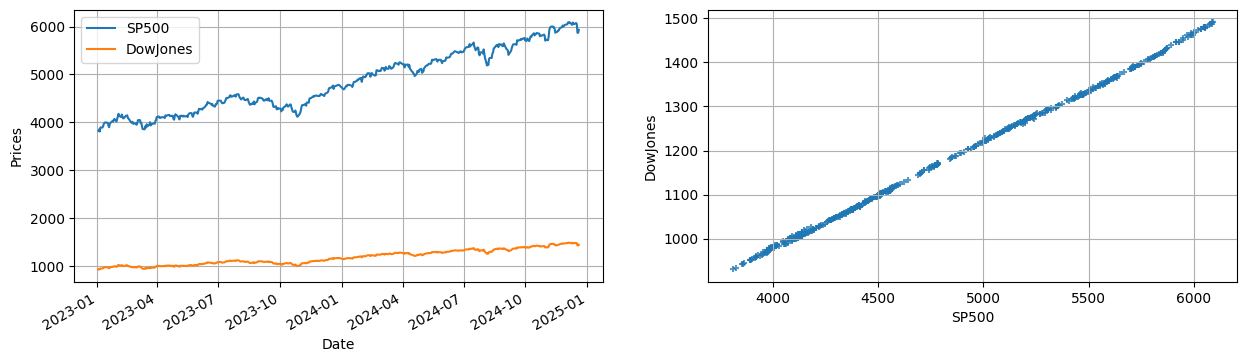

In [3]:
x_ticker='SP500'
y_ticker='DowJones'
fig,axs=plt.subplots(1,2,figsize=(15,4))
train_df.plot.scatter(x=x_ticker,y=y_ticker,marker='+',alpha=.75,ax=axs[1])
axs[1].grid('on')
train_df.plot(y=x_ticker,ax=axs[0])
train_df.plot(y=y_ticker,ax=axs[0])
axs[0].grid('on')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Prices')
plt.savefig(f'{x_ticker}_vs_{y_ticker}_2023_2024.png', bbox_inches='tight')
plt.show()

In [5]:
import tensorflow as tf

def create_linear_regression_model(input_dim):
   '''
   Create a linear regression model
   Inputs:
   input_dim: input dimention
   Outputs:
   model: linear regression model
   '''
   inputs = tf.keras.Input(shape=(input_dim,))
   outputs = tf.keras.layers.Dense(units=1,activation='linear',name='prediction_layer')(inputs)
   model = tf.keras.Model(inputs,outputs,name='linear_regression')
   return model

In [7]:
import numpy as np

train_samples=train_df[[x_ticker]].values.astype(np.float32)
targets=np.array(train_df[[y_ticker]].values.astype(np.float32))
input_dim=train_samples.shape[1]
model=create_linear_regression_model(input_dim=input_dim)

learning_rate=0.01
optimizer=tf.keras.optimizers.Adam(learning_rate)
nb_descent_steps=500
batch_size=264

learning_rate = 0.01
optimizer = tf.keras.optimizers.Adam(learning_rate)
model.compile(optimizer=optimizer,loss='mean_squared_error', metrics=['mean_absolute_error'])

nb_epochs = 200
history = model.fit(train_samples,targets,batch_size=256,epochs=nb_epochs)


Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 24764760.0000 - mean_absolute_error: 4932.8638 
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 23550122.0000 - mean_absolute_error: 4810.6367
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 22852298.0000 - mean_absolute_error: 4738.6318
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 21574848.0000 - mean_absolute_error: 4604.0522
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 21038888.0000 - mean_absolute_error: 4546.6548
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 20157408.0000 - mean_absolute_error: 4450.4092
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 19122814.0000 - mean_absolute_error: 4334.9736
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 18359432.0000 - mean_absolute_error: 4247.7729
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 17427612.0000 - mean_absolute_error: 4137.9512
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - l

In [9]:
weights=model.layers[1].get_weights()
w0=weights[1][0]
w1=weights[0][0]
print(f"w0={w0} w1={w1}")

w0=1.0182236433029175 w1=[0.24359827]


In [ ]:
raw_test_df= yf.download(tickers, start="2025-01-02", end="2025-12-21")
test_df=raw_test_df['Close'].dropna()
test_df.rename(columns=renaming_dict,inplace=True)

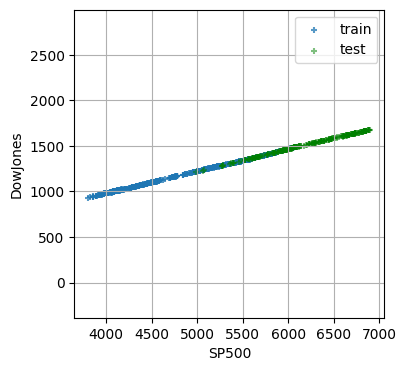

In [15]:
fig,ax=plt.subplots(1,1,figsize=(4,4))
train_df.plot.scatter(x='SP500',y='DowJones',marker='+',alpha=.75,ax=ax)
test_df.plot.scatter(x='SP500',y='DowJones',marker='+',alpha=.5,ax=ax,color='g')
ax.legend(['train', 'test'])
ax.grid('on')
ax.axis('equal')
plt.show()

/tmp/ipython-input-995841664.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_test_df= yf.download(tickers, start="2025-01-02", end="2025-12-21")
[*********************100%***********************]  7 of 7 completed


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


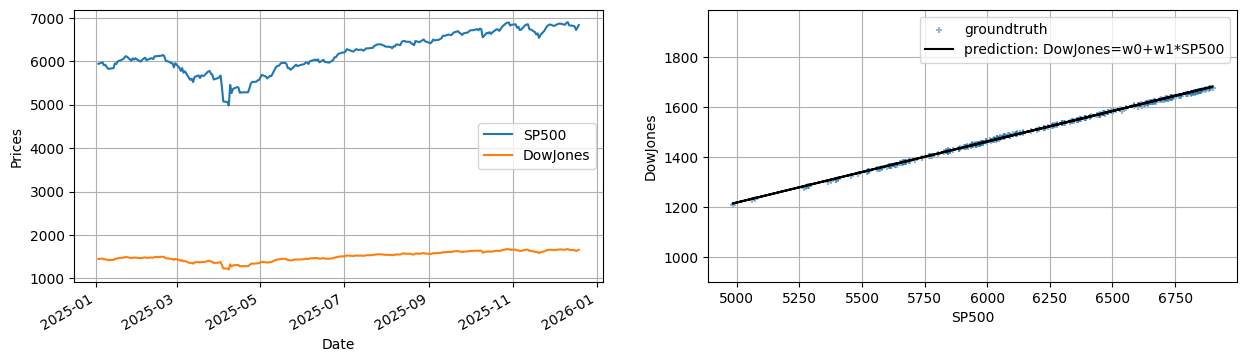

In [10]:
test_samples=test_df[[x_ticker]].values.astype(np.float32)
predictions=model.predict(test_samples)

fig,axs=plt.subplots(1,2,figsize=(15,4))
test_df.plot(y=x_ticker,ax=axs[0])
test_df.plot(y=y_ticker,ax=axs[0])
axs[0].grid('on')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Prices')
test_df.plot.scatter(x=x_ticker,y=y_ticker,marker='+',alpha=.5,label='groundtruth',ax=axs[1])
axs[1].plot(test_samples,predictions,c='k',label=f'prediction: {y_ticker}=w0+w1*{x_ticker}')
axs[1].grid('on')
axs[1].legend()
plt.axis('equal')
plt.savefig(f'{x_ticker}_{y_ticker}_2025_regression_test.png',bbox_inches='tight')
plt.show()